Prédiction de l'iC-Apex par deep learning

Covariables attendues (rasters .tif au même SCR et résolution) :
  - alt        : altitude (m)
  - ru         : réserve utile (classes)
  - cwb_XXXX   : Climate Water Balance par année
 
Variable cible :
  - probabilité de non-stress hydrique : valeur continue

Approche visant une prédiction de la probabilité de non-stress hydrique (classification en deux classes : 0 stress, 1 non-stress), utilisant une loss BCE. Prédit la probabilité que l'observation appartienne à la classe "croissance active". Intégration du MC dropout pour le calcul de l'incertitude associée. Intégration des KFold pour le split.
 
Auteur : Thomas JUILLAC

# 0. IMPORTS

In [31]:
# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Core libraries
import numpy as np
import pandas as pd
import glob
import os
from tqdm import tqdm
import verde as vd

# Geospatial libraries
import rasterio
from rasterio.windows import from_bounds
from rasterio.plot import show
import geopandas as gpd
from shapely.geometry import box

# Machine Learning
import torch
from sklearn.preprocessing import StandardScaler

# Visualization
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


# 1. LOAD APEX-VIGNE DATASET

1.1 LOAD DATASET

In [32]:
# Load the apex-vigne dataset
df = pd.read_csv('data/data_apex.csv', encoding='latin1', low_memory=False)

print(f"📊 Dataset shape: {df.shape[0]:,} observations × {df.shape[1]} columns")
print(f"\n🔤 Available columns:\n{df.columns.tolist()[:15]}...")

# Display first few rows
df.head(3)

📊 Dataset shape: 46,403 observations × 20 columns

🔤 Available columns:
['id_session', 'date_creation', 'date_maj', 'date_session', 'apex0', 'apex1', 'apex2', 'id_observateur', 'id_parcelle', 'id_stade', 'commentaire', 'device_hardware', 'device_software', 'longitude', 'latitude']...


,id_session,date_creation,date_maj,date_session,apex0,apex1,apex2,id_observateur,id_parcelle,id_stade,commentaire,device_hardware,device_software,longitude,latitude,location,en_parcelle,est_archivee,raison_archive,app_version
0,00020b39-e765-4337-999a-63e1f59aca46,2025-08-19 13:43:38,2025-08-19 13:43:38,2025-07-24,4,37,9,4e5e6f16-d26c-428e-a387-007533fa7be9,5843944e-d9d2-48cc-95c8-8d639807b031,NaN,NaN,iPhone,iOS 18.5,6.132792,45.550099,NaN,1.0,0,NaN,6.2.0
1,00041c61510442e5a64fb3af8ce11e24,2024-05-02 12:16:41,2025-04-18 08:46:16,2024-05-02,35,15,2,70c659af882b42ffb6b9415995434669,2f635c3720504254aebd2687712b0c8b,st-H-57-57,NaN,iPhone,iOS 17.4.1,3.544615,43.533837,NaN,1.0,0,NaN,NaN
2,0007ba68-e4f1-3fbd-82a9-336c7718bb2a,2020-06-25 04:27:02,2025-04-18 08:45:29,2019-07-10,13,31,6,edb6d513-eb76-4ad0-ae8a-0be7770048eb,5241d050-de2c-d5e5-a9f7-59f03c2e12ea,NaN,NaN,samsung SM-A715F,Android 11,NaN,NaN,NaN,0.0,0,NaN,NaN


1.2 FILTER ON DATE

In [33]:
#Filtrer les observations par date

# Paramètres à modifier
date_debut = "2025-07-14"
date_fin   = "2025-07-20"

# Filtrage temporel
df['date_session'] = pd.to_datetime(df['date_session'], errors='coerce')
df_filtered = df[(df['date_session'] >= date_debut) & (df['date_session'] <= date_fin)]

print(f"📅 Période sélectionnée : {date_debut} → {date_fin}")
print(f"📊 Observations totales  : {len(df):,}")
print(f"📊 Après filtrage        : {len(df_filtered):,} ({len(df_filtered)/len(df)*100:.1f}%)")
print(f"\n📋 Période couverte par les données filtrées :")
print(f"   De : {df_filtered['date_session'].min().date()}")
print(f"   À  : {df_filtered['date_session'].max().date()}")

📅 Période sélectionnée : 2025-07-14 → 2025-07-20
📊 Observations totales  : 46,403
📊 Après filtrage        : 1,257 (2.7%)

📋 Période couverte par les données filtrées :
   De : 2025-07-14
   À  : 2025-07-20


1.3 FILTER ON LOCATION

In [34]:
# Conversion en objet spatial
data_sf = (df_filtered
    .assign(
        longitude = pd.to_numeric(df['longitude'].replace("NULL", pd.NA), errors='coerce'),
        latitude  = pd.to_numeric(df['latitude'].replace("NULL", pd.NA),  errors='coerce')
    )
    .dropna(subset=['longitude', 'latitude'])
    .pipe(lambda d: gpd.GeoDataFrame(
        d,
        geometry=gpd.points_from_xy(d['longitude'], d['latitude']),
        crs="EPSG:4326"
    ))
)

In [35]:
# Filtrer les observations dans la zone d'étude
study_zone = gpd.read_file("data/study_zone_agri.gpkg")
data_sf_proj = data_sf.to_crs(study_zone.crs)
data_zone = data_sf_proj[data_sf_proj.within(study_zone.union_all())]

data_zone = data_sf_proj[data_sf_proj.within(study_zone.union_all())].copy()

# Calcul de l'iG-APEX
data_zone['ig_apex'] = (data_zone['apex0'] + 0.5 * data_zone['apex1']) / (
    data_zone['apex0'] + data_zone['apex1'] + data_zone['apex2']
)

print(f"📊 Avant filtre zone : {len(data_sf_proj):,} observations")
print(f"📊 Après filtre zone : {len(data_zone):,} observations")
print(f"   Soit {len(data_zone)/len(data_sf_proj)*100:.1f}% des observations retenues")

📊 Avant filtre zone : 1,247 observations
📊 Après filtre zone : 823 observations
   Soit 66.0% des observations retenues


# 2. DATA VISUALISATION (ALREADY DONE IN R)

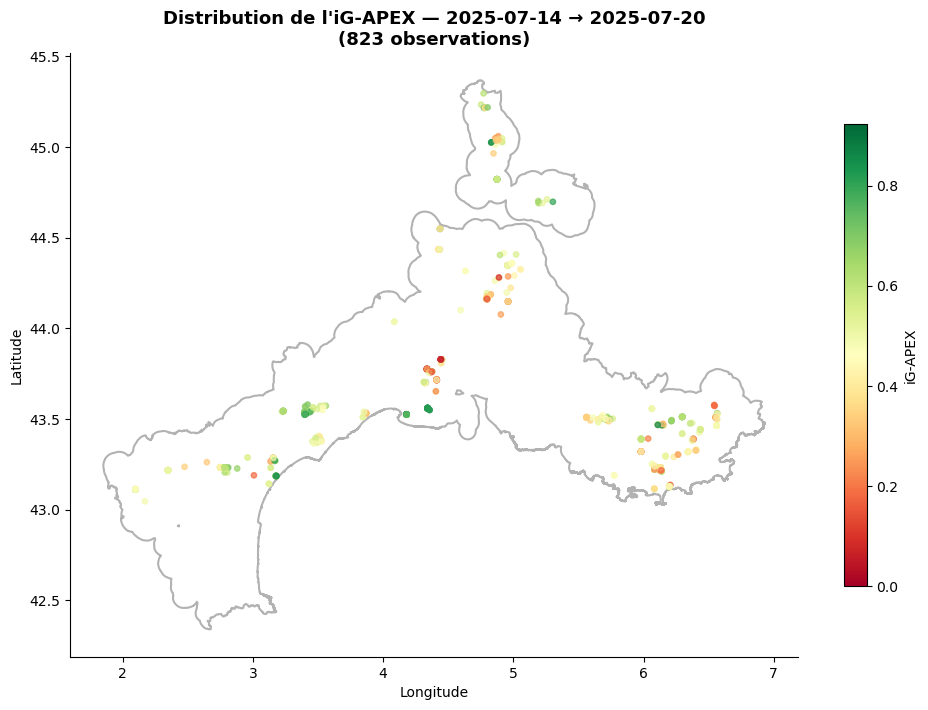

In [36]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Reprojection en WGS84 pour affichage cohérent
study_zone_wgs = study_zone.to_crs("EPSG:4326")
data_zone_wgs  = data_zone.to_crs("EPSG:4326")

# Contour de la zone d'étude
study_zone_wgs.plot(
    ax=ax,
    facecolor='none',
    edgecolor='black',
    linewidth=1.5,
    alpha=0.3
)

# Points colorés par iG-APEX
data_zone_wgs.plot(
    ax=ax,
    column='ig_apex',
    cmap='RdYlGn',
    markersize=15,
    alpha=0.7,
    legend=True,
    legend_kwds={'label': 'iG-APEX', 'shrink': 0.6}
)

ax.set_title(
    f"Distribution de l'iG-APEX — {date_debut} → {date_fin}\n"
    f"({len(data_zone_wgs):,} observations)",
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [37]:
print(data_zone.columns.tolist())

['id_session', 'date_creation', 'date_maj', 'date_session', 'apex0', 'apex1', 'apex2', 'id_observateur', 'id_parcelle', 'id_stade', 'commentaire', 'device_hardware', 'device_software', 'longitude', 'latitude', 'location', 'en_parcelle', 'est_archivee', 'raison_archive', 'app_version', 'geometry', 'ig_apex']


# 3. LOAD STUDY ZONE (GRID)

In [38]:
grid = gpd.read_file("data/study_zone_grid.gpkg")
grid.head()

,id,left,top,right,bottom,row_index,col_index,geometry
0,233,593491.216894,6.243619e+06,594491.216894,6.242619e+06,232,0,"MULTIPOLYGON (((594147.893 6242691.759, 594182..."
1,234,593491.216894,6.242619e+06,594491.216894,6.241619e+06,233,0,"MULTIPOLYGON (((594077.807 6241631.64, 594057...."
2,235,593491.216894,6.241619e+06,594491.216894,6.240619e+06,234,0,"MULTIPOLYGON (((594487.234 6240783.55, 594463...."
3,236,593491.216894,6.240619e+06,594491.216894,6.239619e+06,235,0,"MULTIPOLYGON (((594113.921 6239641.903, 594131..."
4,237,593491.216894,6.239619e+06,594491.216894,6.238619e+06,236,0,"MULTIPOLYGON (((594472.355 6239234.844, 594419..."


# 4. RASTERS

In [39]:
# Sélection des covariables CWB
CWB_MODE = "single"       # "none" | "single" | "multi"
CWB_YEAR = 2025          # utilisé seulement si CWB_MODE == "single"
CWB_YEARS = [2020, 2021, 2022, 2023, 2024, 2025]  # utilisé seulement si CWB_MODE == "multi"

# Lister tous les rasters dans les sous-dossiers
subfolders = ['alt', 'ru']  # CWB géré séparément
raster_files = []
for sub in subfolders:
    files = sorted(glob.glob(f'data/cov/rasters/{sub}/*.tif'))
    raster_files.extend(files)

# Ajout des fichiers CWB selon le mode
if CWB_MODE == "single":
    cwb_files = sorted(glob.glob(f'data/cov/rasters/cwb/ClimaticWaterBalance{CWB_YEAR}.tif'))
elif CWB_MODE == "multi":
    cwb_files = sorted([
        f'data/cov/rasters/cwb/ClimaticWaterBalance{yr}.tif'
        for yr in CWB_YEARS
        if glob.glob(f'data/cov/rasters/cwb/ClimaticWaterBalance{yr}.tif')
    ])
else:  # "none"
    cwb_files = []

raster_files.extend(cwb_files)

print(f"📂 {len(raster_files)} rasters trouvés (CWB mode: {CWB_MODE}) :\n")
for f in raster_files:
    with rasterio.open(f) as src:
        res = abs(src.transform[0])
        print(f"   {f}")
        print(f"      Dimensions : {src.width} × {src.height} pixels")
        print(f"      Résolution : {res:.0f} m\n")

📂 3 rasters trouvés (CWB mode: single) :

   data/cov/rasters/alt\altitude_study_zone.tif
      Dimensions : 424 × 337 pixels
      Résolution : 1000 m

   data/cov/rasters/ru\ru_raster.tif
      Dimensions : 425 × 336 pixels
      Résolution : 1000 m

   data/cov/rasters/cwb/ClimaticWaterBalance2025.tif
      Dimensions : 423 × 338 pixels
      Résolution : 1000 m



# 5. VISUALISATION OF COVARIABLES

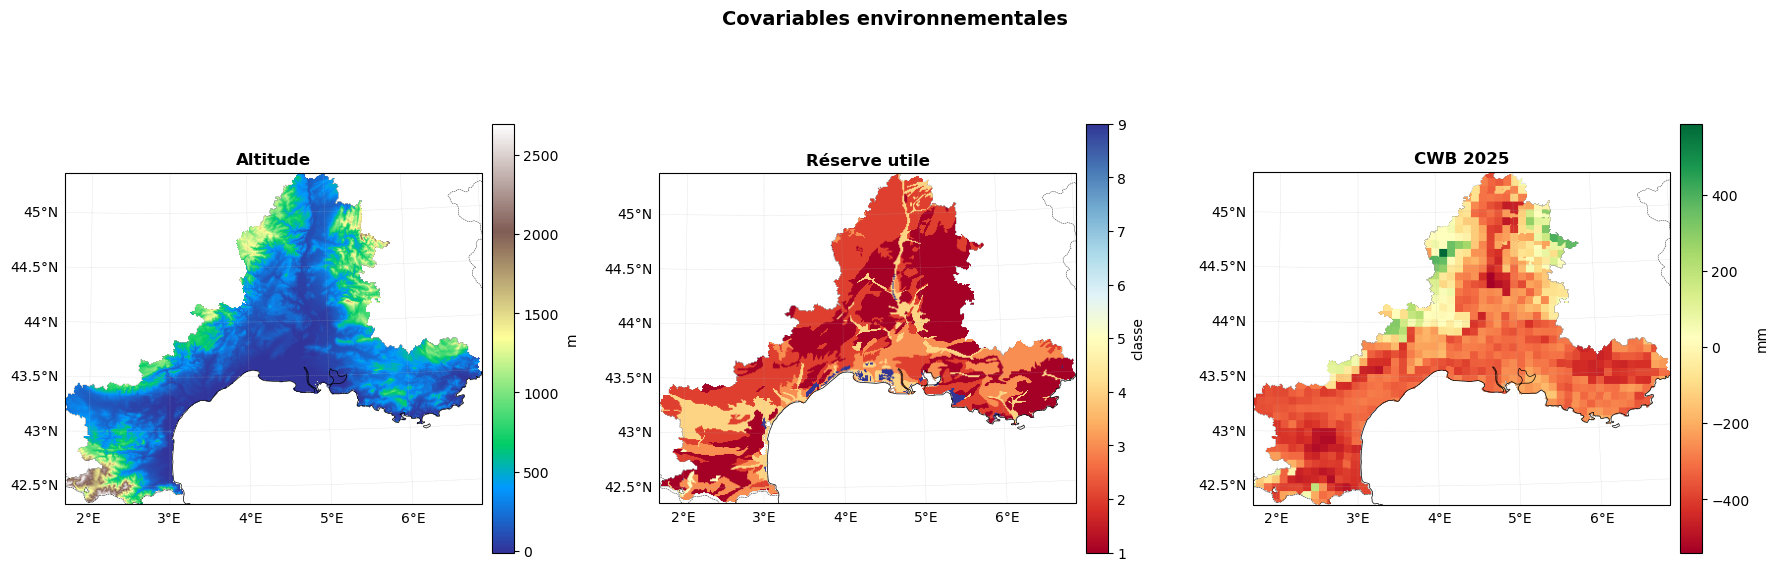

In [40]:
variables_to_plot = [
    ('data/cov/rasters/alt/altitude_study_zone.tif',          'Altitude',      'm',     'terrain'),
    ('data/cov/rasters/ru/ru_raster.tif',                     'Réserve utile', 'classe','RdYlBu'),
    ('data/cov/rasters/cwb/ClimaticWaterBalance2025.tif',      'CWB 2025',      'mm',    'RdYlGn'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6),
                         subplot_kw={'projection': ccrs.epsg(2154)})

for ax, (filepath, title, unit, cmap) in zip(axes, variables_to_plot):
    with rasterio.open(filepath) as src:
        data   = src.read(1).astype(np.float32)
        extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
        nodata = src.nodata

        if nodata is not None:
            data = np.ma.masked_where((data == nodata) | ~np.isfinite(data), data)
        else:
            data = np.ma.masked_where(
                (data <= -9999) | (data == 0) | ~np.isfinite(data), data
            )

    ax.set_facecolor('none')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.3, linestyle='--')

    im = ax.imshow(data, extent=extent, origin='upper', cmap=cmap,
                   transform=ccrs.epsg(2154))

    cbar = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
    cbar.set_label(unit, fontsize=10)

    gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5, linestyle='--')
    gl.top_labels   = False
    gl.right_labels = False

    ax.set_title(title, fontsize=12, fontweight='bold')

plt.suptitle('Covariables environnementales', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 6. PREPARE TRAINING DATA

6.1 RASTER PROPERTIES

In [41]:
# Get raster properties from the first raster
with rasterio.open(raster_files[0]) as src:
    raster_resolution = abs(src.transform[0])
    raster_transform  = src.transform
    raster_crs        = src.crs

print(f"📐 Résolution : {raster_resolution:.0f} m")
print(f"🌐 SCR : {raster_crs}")
print(f"📁 Nombre de variables : {len(raster_files)}")
print(f"\n📋 Variables :")
for i, f in enumerate(raster_files, 1):
    print(f"   {i:2d}. {os.path.basename(f)}")

📐 Résolution : 1000 m
🌐 SCR : EPSG:2154
📁 Nombre de variables : 3

📋 Variables :
    1. altitude_study_zone.tif
    2. ru_raster.tif
    3. ClimaticWaterBalance2025.tif


6.2 iG-APEX calculation

In [42]:
# Calcul de l'iG-APEX
data_zone = data_zone.copy()
data_zone['date_session'] = pd.to_datetime(data_zone['date_session']).dt.date
data_zone['ig_apex'] = (data_zone['apex0'] + data_zone['apex1'] * 0.5) / \
                       (data_zone['apex0'] + data_zone['apex1'] + data_zone['apex2'])

print(f"📍 Observations brutes      : {len(df):,}")
print(f"📍 Après nettoyage spatial  : {len(data_sf):,}")
print(f"📍 Dans la zone d'étude     : {len(data_zone):,}")
print(f"\n📋 Aperçu iG-APEX :")
print(data_zone['ig_apex'].describe().round(3))

📍 Observations brutes      : 46,403
📍 Après nettoyage spatial  : 1,247
📍 Dans la zone d'étude     : 823

📋 Aperçu iG-APEX :
count    823.000
mean       0.465
std        0.184
min        0.000
25%        0.350
50%        0.481
75%        0.570
max        0.924
Name: ig_apex, dtype: float64


6.3 CREATION OF TENSORS

In [43]:
# Coordonnées des centroïdes de la grille en Lambert
grid_proj = grid.to_crs("EPSG:2154")
centroids = [(geom.centroid.x, geom.centroid.y) for geom in grid_proj.geometry]
num_cells = len(grid_proj)
num_variables = len(raster_files)

print(f"📍 Nombre de cellules : {num_cells:,}")
print(f"📁 Nombre de variables : {num_variables}")

# Tenseur X — valeurs environnementales
X_tensor = torch.zeros((num_cells, num_variables), dtype=torch.float32)

print("\n🌡️ Extraction des valeurs des covariables...")
for var_idx, filepath in enumerate(tqdm(raster_files, desc="Processing rasters")):
    with rasterio.open(filepath) as src:
        nodata = src.nodata
        values = np.array([val[0] for val in src.sample(centroids)], dtype=np.float32)
        if nodata is not None:
            values[values == nodata] = np.nan
        X_tensor[:, var_idx] = torch.tensor(values, dtype=torch.float32)

print(f"\n✅ Tenseur X créé !")

📍 Nombre de cellules : 50,998
📁 Nombre de variables : 3

🌡️ Extraction des valeurs des covariables...


Processing rasters: 100%|████████████████████████████████████████████████████████████████| 3/3 [00:03<00:00,  1.19s/it]


✅ Tenseur X créé !


In [44]:
# Index de la colonne RU dans all_raster_files
ru_idx = next(i for i, f in enumerate(raster_files) if 'ru' in f.lower())

# Valeurs RU brutes
ru_values = X_tensor[:, ru_idx].numpy()

# Classes attendues (9 = non-sol traité séparément)
ru_classes = [1, 2, 3, 4, 5, 9]

# One-hot encoding
ru_onehot = np.zeros((num_cells, len(ru_classes)), dtype=np.float32)
for j, cls in enumerate(ru_classes):
    ru_onehot[:, j] = (ru_values == cls).astype(np.float32)

# Remplacement de la colonne RU par les colonnes one-hot
X_np = X_tensor.numpy()
X_np_without_ru = np.delete(X_np, ru_idx, axis=1)
X_tensor = torch.tensor(
    np.concatenate([X_np_without_ru, ru_onehot], axis=1),
    dtype=torch.float32
)

# Mise à jour du nombre de variables
num_variables = X_tensor.shape[1]

print(f"✅ RU encodée en one-hot ({len(ru_classes)} classes) et tenseur X mis à jour")
print(f"   X (covariables) : {X_tensor.shape}")

✅ RU encodée en one-hot (6 classes) et tenseur X mis à jour
   X (covariables) : torch.Size([50998, 8])


In [45]:
# Seuil de binarisation iG-APEX
IG_APEX_THRESHOLD = 0.5  # >= seuil → présence (1), < seuil → absence (0)

# Tenseur y — iG-APEX binarisé par cellule de grille
print("\n🔢 Construction du tenseur y (présence/absence par case)...")
data_zone_proj = data_zone.to_crs("EPSG:2154")
grid_with_idx  = grid_proj.copy()
grid_with_idx['cell_idx'] = range(num_cells)

# Jointure spatiale observations -> cellules
joined = gpd.sjoin(data_zone_proj[['ig_apex', 'geometry']],
                   grid_with_idx[['cell_idx', 'geometry']],
                   how='left', predicate='within')

# Moyenne de l'iG-APEX par cellule puis binarisation
ig_mean   = joined.groupby('cell_idx')['ig_apex'].mean()
ig_mean   = ig_mean.dropna()
ig_binary = (ig_mean >= IG_APEX_THRESHOLD).astype(float)

# Tenseur y binaire
y_tensor = torch.zeros((num_cells,), dtype=torch.float32)
y_tensor[ig_binary.index] = torch.tensor(ig_binary.values, dtype=torch.float32)

# Masque — cellules observées uniquement
observed_mask = torch.zeros(num_cells, dtype=torch.bool)
observed_mask[ig_binary.index] = True

# Exclure les non-sols (RU == 9)
nonsoil_mask  = torch.tensor(ru_values == 9)
observed_mask = observed_mask & ~nonsoil_mask

print(f"\n✅ Tenseur y créé !")
print(f"   Seuil iG-APEX                     : {IG_APEX_THRESHOLD}")
print(f"   y (présence/absence par cellule)  : {y_tensor.shape}")
print(f"   Présences  (1)                    : {(y_tensor[observed_mask] == 1).sum().item():,}")
print(f"   Absences   (0)                    : {(y_tensor[observed_mask] == 0).sum().item():,}")
print(f"   Ratio présences                   : {(y_tensor[observed_mask] == 1).sum().item() / observed_mask.sum().item()*100:.1f}%")
print(f"   Cellules non-sol exclues          : {nonsoil_mask.sum().item():,}")
print(f"   Cellules masquées (non observées) : {(~observed_mask).sum().item():,} / {num_cells:,}")


🔢 Construction du tenseur y (présence/absence par case)...

✅ Tenseur y créé !
   Seuil iG-APEX                     : 0.5
   y (présence/absence par cellule)  : torch.Size([50998])
   Présences  (1)                    : 92
   Absences   (0)                    : 101
   Ratio présences                   : 47.7%
   Cellules non-sol exclues          : 644
   Cellules masquées (non observées) : 50,805 / 50,998


## 7. DATA QUALITY CHECK & STATISTICS

In [46]:
# Check for missing values
nan_mask = torch.isnan(X_tensor)
rows_with_nan = nan_mask.any(dim=1).sum().item()
total_nan = nan_mask.sum().item()

print(f"📈 Feature Statistics:")
for i, fname in enumerate(raster_files):
    var_name = fname.replace('data/cov/rasters/', '').replace('.tif', '')
    values = X_tensor[:, i]
    valid_values = values[~torch.isnan(values)]
    if len(valid_values) == 0:
        print(f"   {var_name}: ⚠️ aucune valeur valide")
    else:
        print(f"   {var_name}: min={valid_values.min():.1f}, max={valid_values.max():.1f}, mean={valid_values.mean():.1f}")

print(f"\n⚠️  Missing Values:")
print(f"   Cellules avec NaN : {rows_with_nan:,} / {num_cells:,} ({100*rows_with_nan/num_cells:.1f}%)")
print(f"   Total NaN         : {total_nan:,}")

📈 Feature Statistics:
   alt\altitude_study_zone: min=-11.1, max=2696.0, mean=407.9
   ru\ru_raster: min=-540.0, max=586.2, mean=-254.2
   cwb/ClimaticWaterBalance2025: min=0.0, max=1.0, mean=0.4

⚠️  Missing Values:
   Cellules avec NaN : 295 / 50,998 (0.6%)
   Total NaN         : 295


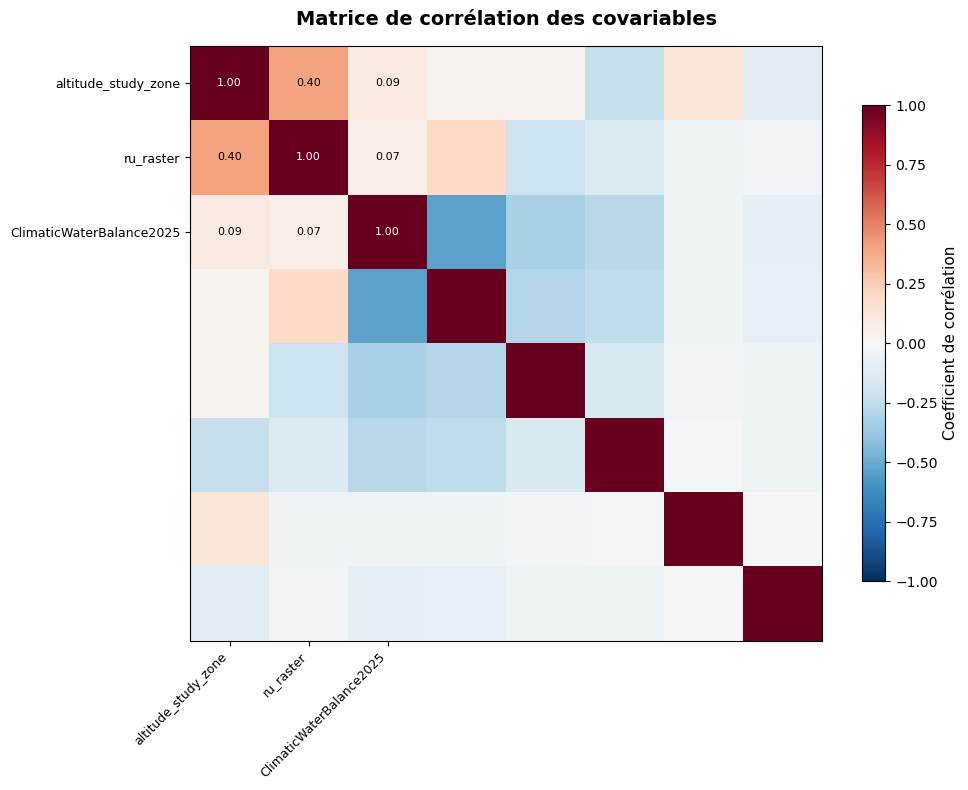


💡 Paires fortement corrélées (|r| > 0.8) :


In [47]:
# Correlation matrix of environmental variables
fig, ax = plt.subplots(figsize=(10, 8))

# Calcul de la matrice de corrélation (en ignorant les NaN)
X_numpy = X_tensor.numpy()
valid_mask = ~np.isnan(X_numpy).any(axis=1)
corr_matrix = np.corrcoef(X_numpy[valid_mask].T)

# Noms de variables nettoyés
var_names = [
    f.replace('data/cov/rasters/', '')
     .replace('alt\\', '').replace('cwb/', '').replace('ru\\', '')
     .replace('.tif', '')
    for f in raster_files
]

# Heatmap
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Coefficient de corrélation', fontsize=11)

# Annotations des valeurs dans chaque cellule
for i in range(len(var_names)):
    for j in range(len(var_names)):
        ax.text(j, i, f'{corr_matrix[i, j]:.2f}', ha='center', va='center',
                fontsize=8, color='black' if abs(corr_matrix[i, j]) < 0.7 else 'white')

ax.set_xticks(range(len(var_names)))
ax.set_yticks(range(len(var_names)))
ax.set_xticklabels(var_names, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(var_names, fontsize=9)
ax.set_title('Matrice de corrélation des covariables', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

# Paires fortement corrélées
print("\n💡 Paires fortement corrélées (|r| > 0.8) :")
for i in range(len(var_names)):
    for j in range(i+1, len(var_names)):
        if abs(corr_matrix[i, j]) > 0.8:
            print(f"   {var_names[i]} ↔ {var_names[j]} : r = {corr_matrix[i, j]:.2f}")

## 8. SPATIAL SPLIT FOR TEST/TRAINING

In [48]:
# Block K-Fold
NUM_CV_BLOCKS   = (5, 5)  # grille de blocs 5×5 sur la zone
N_SPLITS        = 5       #  3folds → ~80% train / 20% val par fold
GLOBAL_SEED     = 42

# Coordonnées lon/lat des cellules observées
obs_indices = np.where(observed_mask.numpy())[0]
grid_wgs84  = grid.to_crs("EPSG:4326")
coords_obs  = np.array([
    (grid_wgs84.geometry.iloc[i].centroid.x,
     grid_wgs84.geometry.iloc[i].centroid.y)
    for i in obs_indices
])
X_lat_long = torch.tensor(coords_obs, dtype=torch.float32)

print(f"📍 Cellules observées : {len(obs_indices)}")
print(f"   Shape X_lat_long  : {X_lat_long.shape}")

📍 Cellules observées : 193
   Shape X_lat_long  : torch.Size([193, 2])


In [49]:
# Tenseurs sur cellules observées uniquement
X_obs = X_tensor[observed_mask]
y_obs = y_tensor[observed_mask]

# Block K-Fold spatial
kfold = vd.BlockKFold(
    shape        = NUM_CV_BLOCKS,
    n_splits     = N_SPLITS,
    shuffle      = True,
    balance      = True,
    random_state = GLOBAL_SEED
).split(X_lat_long.numpy())

# Construction des datasets par fold
x_trains, y_trains = [], []
x_vals,   y_vals   = [], []

for ind_train, ind_val in kfold:
    x_trains.append(X_obs[ind_train])
    y_trains.append(y_obs[ind_train])
    x_vals.append(X_obs[ind_val])
    y_vals.append(y_obs[ind_val])

print(f"✅ {N_SPLITS} folds créés :")
for i in range(N_SPLITS):
    n_train = len(x_trains[i])
    n_val   = len(x_vals[i])
    n_pos_t = y_trains[i].sum().item()
    n_pos_v = y_vals[i].sum().item()
    print(f"   Fold {i+1} — Train : {n_train} ({n_pos_t:.0f} présences) "
          f"| Val : {n_val} ({n_pos_v:.0f} présences)")

✅ 5 folds créés :
   Fold 1 — Train : 165 (80 présences) | Val : 28 (12 présences)
   Fold 2 — Train : 151 (67 présences) | Val : 42 (25 présences)
   Fold 3 — Train : 154 (76 présences) | Val : 39 (16 présences)
   Fold 4 — Train : 154 (68 présences) | Val : 39 (24 présences)
   Fold 5 — Train : 148 (77 présences) | Val : 45 (15 présences)


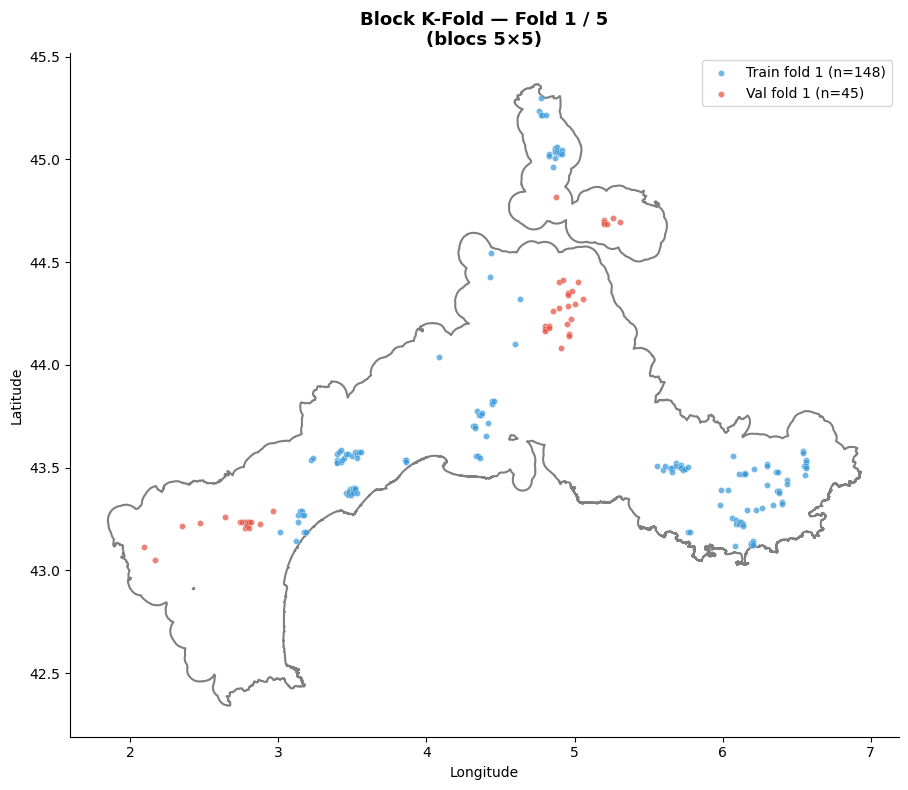

In [50]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
study_zone_wgs = study_zone.to_crs("EPSG:4326")
study_zone_wgs.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.5, alpha=0.5)

# Recréer le kfold pour visualisation
kfold_viz = vd.BlockKFold(
    shape        = NUM_CV_BLOCKS,
    n_splits     = N_SPLITS,
    shuffle      = True,
    balance      = False,
    random_state = GLOBAL_SEED
).split(X_lat_long.numpy())

for fold_idx, (ind_train, ind_val) in enumerate(kfold_viz):
    if fold_idx == 0:
        train_coords_f1 = coords_obs[ind_train]
        val_coords_f1   = coords_obs[ind_val]
        break

ax.scatter(train_coords_f1[:, 0], train_coords_f1[:, 1],
           c='#3498db', s=20, alpha=0.7, label=f'Train fold 1 (n={len(train_coords_f1)})',
           edgecolor='white', linewidth=0.3)
ax.scatter(val_coords_f1[:, 0], val_coords_f1[:, 1],
           c='#e74c3c', s=20, alpha=0.7, label=f'Val fold 1 (n={len(val_coords_f1)})',
           edgecolor='white', linewidth=0.3)

ax.set_title(f'Block K-Fold — Fold 1 / {N_SPLITS}\n(blocs {NUM_CV_BLOCKS[0]}×{NUM_CV_BLOCKS[1]})',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 9. MODEL TRAINING

# 9.1 MODEL CONFIGURATION AND TRAINING

In [51]:
# Additional imports for training
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import copy

# Training configuration
class Args:
    def __init__(self):
        self.learning_rate = 0.0001
        self.epoch         = 75
        self.hidden_nbr    = 2
        self.weight_decay  = 1e-3
        self.batch_size    = 16

args = Args()

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  Device : {device}")

# Paramètres du modèle
input_size  = X_obs.shape[1]  # nb covariables — X_obs existe toujours
output_size = 1
hidden_size = 64

# Nombre de colonnes continues (tout sauf les one-hot RU)
n_onehot     = len(ru_classes)  # 6
n_continuous = X_obs.shape[1] - n_onehot

print(f"   Colonnes continues : {n_continuous}")
print(f"   Colonnes one-hot   : {n_onehot}")

print(f"\n🧠 Architecture du modèle :")
print(f"   Input  : {input_size} covariables")
print(f"   Hidden : {hidden_size} × {args.hidden_nbr} couches")
print(f"   Output : {output_size} (iG-APEX)")

print(f"\n⚙️  Configuration d'entraînement :")
print(f"   Learning rate : {args.learning_rate}")
print(f"   Epochs        : {args.epoch}")
print(f"   Weight decay  : {args.weight_decay}")
print(f"   Batch size    : {args.batch_size}")

🖥️  Device : cuda
   Colonnes continues : 2
   Colonnes one-hot   : 6

🧠 Architecture du modèle :
   Input  : 8 covariables
   Hidden : 64 × 2 couches
   Output : 1 (iG-APEX)

⚙️  Configuration d'entraînement :
   Learning rate : 0.0001
   Epochs        : 75
   Weight decay  : 0.001
   Batch size    : 16


9.2 TRAINING LOOPS WITH VALIDATION RMSE

In [52]:
import torch.nn as nn

class mlp_model(nn.Module):
    def __init__(self, input_size, hidden_size, hidden_nbr, dropout_p=0.2):
        super(mlp_model, self).__init__()
        self.dropout_p = dropout_p
        layers = []

        layers += [
            nn.Linear(input_size, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),
            nn.Dropout(p=dropout_p)
        ]
        for _ in range(hidden_nbr - 1):
            layers += [
                nn.Linear(hidden_size, hidden_size),
                nn.BatchNorm1d(hidden_size),
                nn.ReLU(),
                nn.Dropout(p=dropout_p)
            ]
        layers.append(nn.Linear(hidden_size, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

    def mc_forward(self, x, n_samples=50):
        """Garde le dropout actif pour l'inférence MC."""
        self.train()  # dropout actif
        with torch.no_grad():
            preds = torch.stack([
                torch.sigmoid(self.network(x)).squeeze()
                for _ in range(n_samples)
            ], dim=0)  # (n_samples, n_cells)
        return preds

In [53]:
def predict_with_uncertainty(model, X_tensor, device, n_samples=100):
    model.train()  # active le dropout
    preds = []
    with torch.no_grad():
        for _ in range(n_samples):
            logits = model(X_tensor.to(device)).squeeze().cpu()
            preds.append(torch.sigmoid(logits))   # ← sigmoid ici, une fois
    preds = torch.stack(preds)  # shape (n_samples, n_cells)
    return preds.mean(dim=0), preds.std(dim=0)    # mean et std dans [0,1]

In [54]:
def train_model(X_train, y_train, X_val, y_val, args, hidden_size=128, device="cpu"):
    """
    Entraînement d'un MLP pour la régression de l'iG-APEX.

    Returns:
        dict : modèle, historique des pertes, meilleur val_loss
    """
    # DataLoader
    train_dataset = TensorDataset(X_train, y_train)
    train_loader  = DataLoader(train_dataset, batch_size=args.batch_size, shuffle=True)

    # Modèle, loss, optimizer
    input_size  = X_train.shape[1]
    model       = mlp_model(input_size, hidden_size, args.hidden_nbr).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer   = optim.Adam(
        model.parameters(),
        lr=args.learning_rate,
        weight_decay=args.weight_decay
    )

    # Historique
    train_losses = []
    val_losses   = []
    best_val_loss    = float('inf')
    best_model_state = None

    print("🚀 Entraînement...")
    print("=" * 60)

    for epoch in tqdm(range(args.epoch), desc="Training"):

        # Phase train
        model.train()
        total_train_loss = 0.0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_X).squeeze()
            loss    = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Phase validation
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val.to(device)).squeeze()
            val_loss    = criterion(val_outputs, y_val.to(device)).item()
        val_losses.append(val_loss)

        # Log tous les 10 epochs
        if (epoch + 1) % 10 == 0 or epoch == 0:
            val_rmse = np.sqrt(val_loss)
            print(f"   Epoch {epoch+1:3d} | Train bce: {avg_train_loss:.4f} | "
                  f"Val bce: {val_loss:.4f} | Val RMSE: {val_rmse:.4f}")

        # Sauvegarde du meilleur modèle
        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            best_model_state = copy.deepcopy(model.state_dict())

    # Rechargement du meilleur état
    if best_model_state is None:
        print("⚠️  Aucun meilleur modèle sauvegardé — val_loss était NaN/inf à chaque epoch")
        print("   Vérification des tenseurs d'entrée :")
        print(f"   X_train NaN : {torch.isnan(X_train).sum().item()}")
        print(f"   y_train NaN : {torch.isnan(y_train).sum().item()}")
        print(f"   y_train inf : {torch.isinf(y_train).sum().item()}")
        return None
    
    model.load_state_dict(best_model_state)

    print("=" * 60)
    print(f"✅ Entraînement terminé ! Meilleur Val bce : {best_val_loss:.4f} "
          f"| RMSE : {np.sqrt(best_val_loss):.4f}")

    return {
        "model"       : model,
        "train_losses": train_losses,
        "val_losses"  : val_losses,
        "best_val_loss": best_val_loss
    }

In [55]:
all_results = []

for fold_idx in range(N_SPLITS):
    print(f"\n{'='*60}")
    print(f"🔁 FOLD {fold_idx + 1} / {N_SPLITS}")
    print(f"{'='*60}")

    # Preprocessing du fold
    X_train_raw = x_trains[fold_idx]
    X_val_raw   = x_vals[fold_idx]
    y_train_f   = y_trains[fold_idx]
    y_val_f     = y_vals[fold_idx]

    # Suppression NaN
    train_nan_mask = torch.isnan(X_train_raw).any(dim=1)
    val_nan_mask   = torch.isnan(X_val_raw).any(dim=1)
    X_train_clean  = X_train_raw[~train_nan_mask]
    y_train_clean  = y_train_f[~train_nan_mask]
    X_val_clean    = X_val_raw[~val_nan_mask]
    y_val_clean    = y_val_f[~val_nan_mask]

    # Normalisation (fit sur train uniquement)
    scaler_fold = StandardScaler()
    X_train_cont_scaled = scaler_fold.fit_transform(X_train_clean[:, :n_continuous].numpy())
    X_val_cont_scaled   = scaler_fold.transform(X_val_clean[:, :n_continuous].numpy())

    X_train_tensor_f = torch.tensor(
        np.concatenate([X_train_cont_scaled, X_train_clean[:, n_continuous:].numpy()], axis=1),
        dtype=torch.float32
    )
    X_val_tensor_f = torch.tensor(
        np.concatenate([X_val_cont_scaled, X_val_clean[:, n_continuous:].numpy()], axis=1),
        dtype=torch.float32
    )

    # Entraînement
    fold_results = train_model(
        X_train     = X_train_tensor_f,
        y_train     = y_train_clean,
        X_val       = X_val_tensor_f,
        y_val       = y_val_clean,
        args        = args,
        hidden_size = hidden_size,
        device      = device
    )

    if fold_results is not None:
        all_results.append({
            "fold"       : fold_idx + 1,
            "results"    : fold_results,
            "scaler"     : scaler_fold,
            "val_loss"   : fold_results["best_val_loss"]
        })

# Résumé
print(f"\n📊 RÉSUMÉ CROSS-VALIDATION")
print("=" * 60)
val_losses = [r["val_loss"] for r in all_results]
print(f"   BCE par fold : {[f'{v:.4f}' for v in val_losses]}")
print(f"   BCE moyenne  : {np.mean(val_losses):.4f} ± {np.std(val_losses):.4f}")

# Meilleur fold
best_fold = all_results[np.argmin(val_losses)]
print(f"   Meilleur fold : Fold {best_fold['fold']} (BCE = {best_fold['val_loss']:.4f})")


🔁 FOLD 1 / 5
🚀 Entraînement...


Training:   4%|██▉                                                                      | 3/75 [00:00<00:02, 27.48it/s]

   Epoch   1 | Train bce: 0.7132 | Val bce: 0.6897 | Val RMSE: 0.8305


Training:  19%|█████████████▍                                                          | 14/75 [00:00<00:01, 34.05it/s]

   Epoch  10 | Train bce: 0.7027 | Val bce: 0.8209 | Val RMSE: 0.9061


...

   Epoch  50 | Train bce: 0.6802 | Val bce: 0.7342 | Val RMSE: 0.8569


Training:  89%|████████████████████████████████████████████████████████████████▎       | 67/75 [00:01<00:00, 45.98it/s]

   Epoch  60 | Train bce: 0.6846 | Val bce: 0.7324 | Val RMSE: 0.8558


Training: 100%|████████████████████████████████████████████████████████████████████████| 75/75 [00:01<00:00, 45.17it/s]

   Epoch  70 | Train bce: 0.6657 | Val bce: 0.7258 | Val RMSE: 0.8520
✅ Entraînement terminé ! Meilleur Val bce : 0.7157 | RMSE : 0.8460

📊 RÉSUMÉ CROSS-VALIDATION
   BCE par fold : ['0.6897', '0.6923', '0.6734', '0.7124', '0.7157']
   BCE moyenne  : 0.6967 ± 0.0156
   Meilleur fold : Fold 3 (BCE = 0.6734)


9.4 VISUALISE TRAINING PROCESS

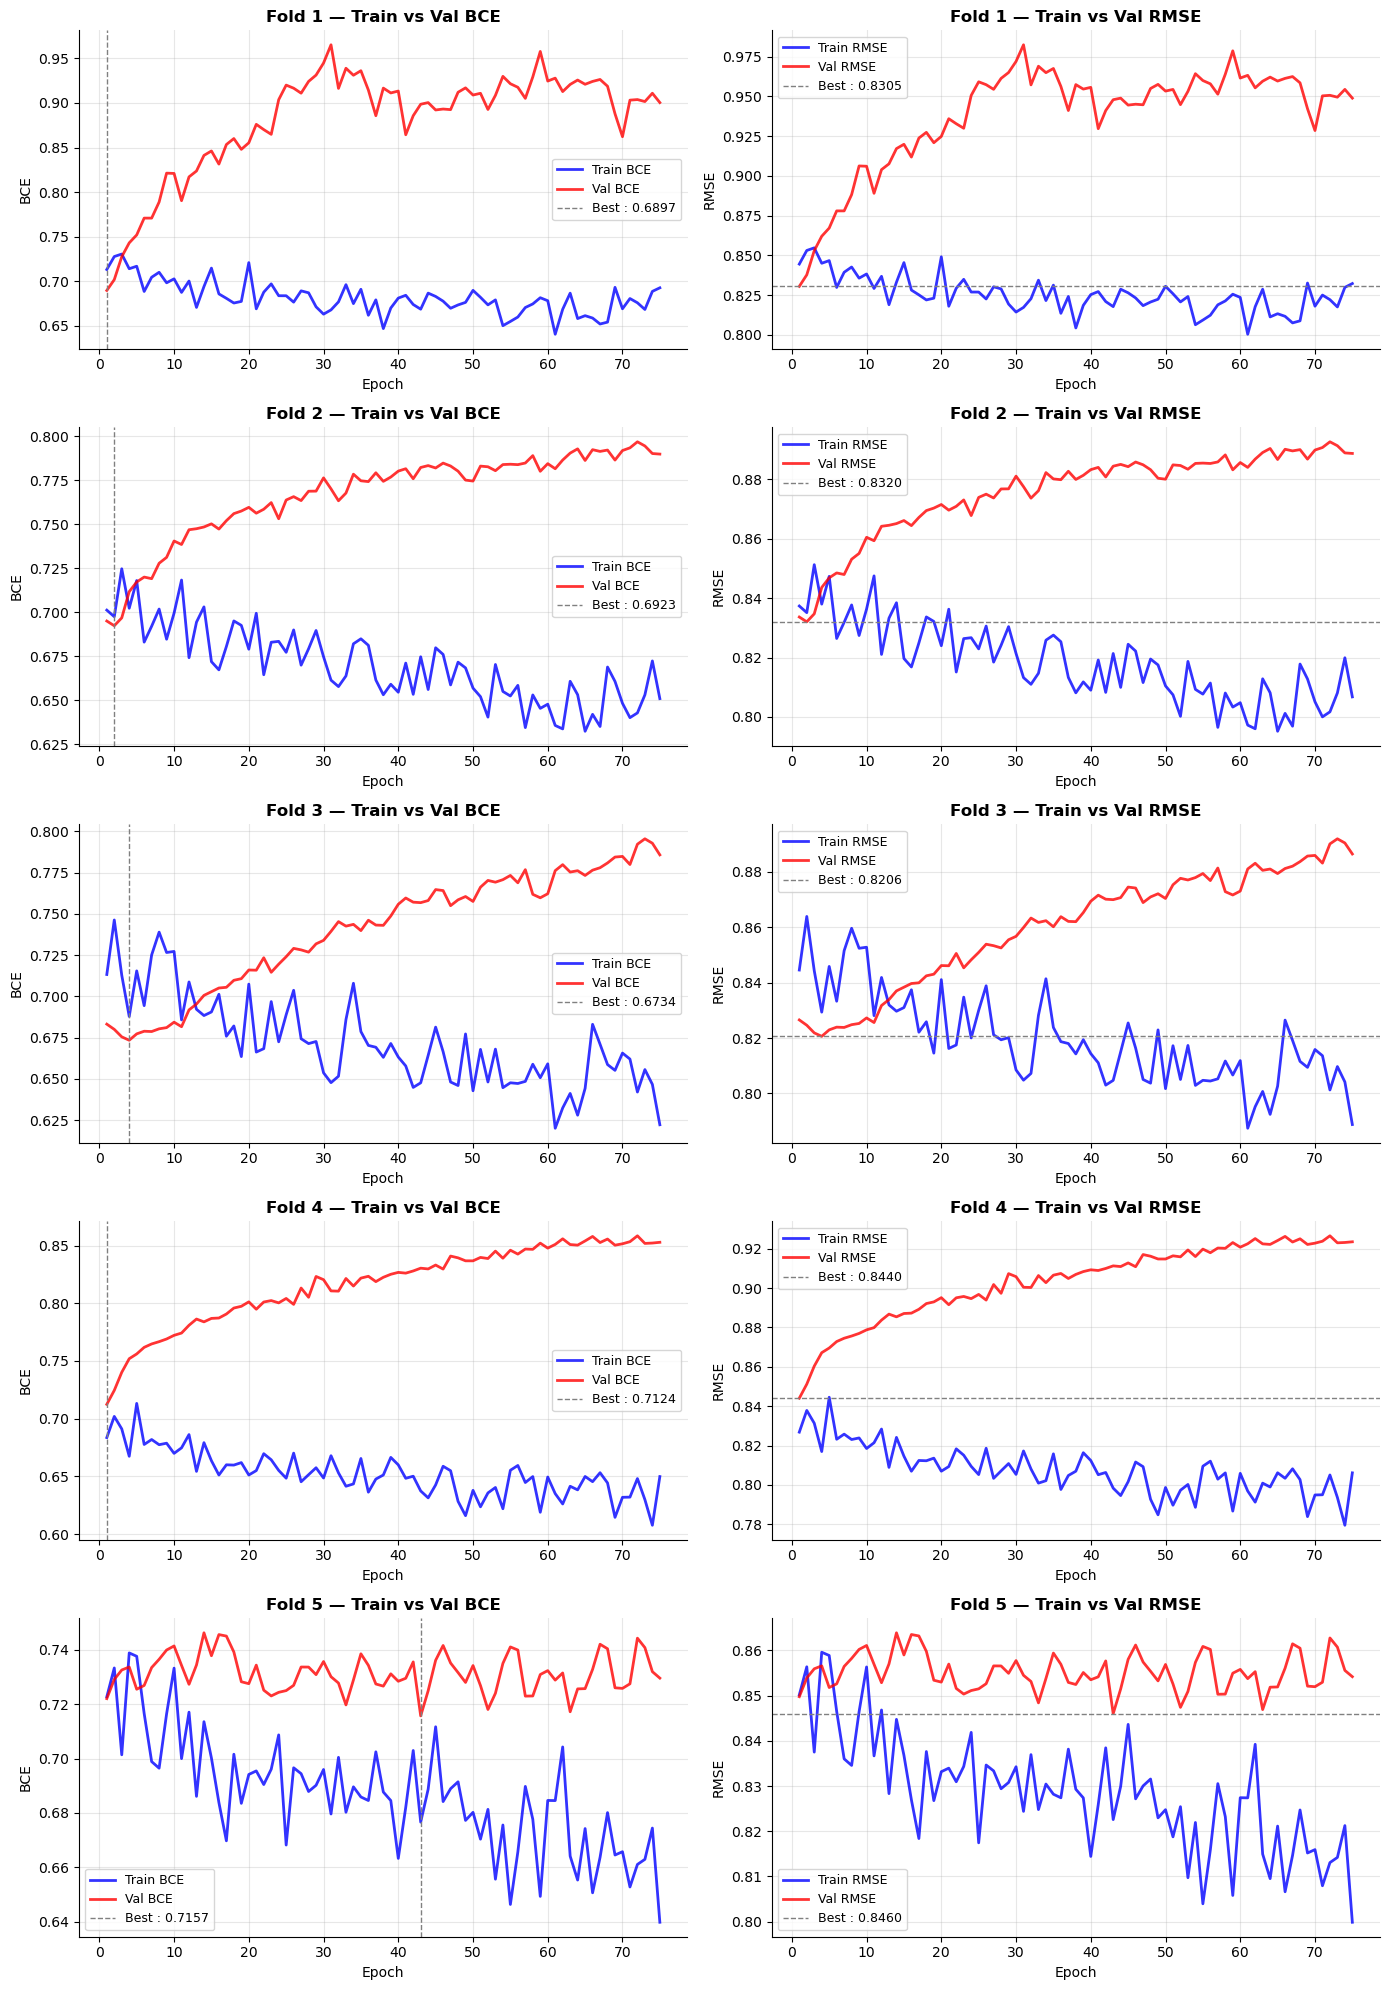


📊 MÉTRIQUES FINALES PAR FOLD
   Fold 1 — BCE : 0.6897 | RMSE : 0.8305
   Fold 2 — BCE : 0.6923 | RMSE : 0.8320
   Fold 3 — BCE : 0.6734 | RMSE : 0.8206
   Fold 4 — BCE : 0.7124 | RMSE : 0.8440
   Fold 5 — BCE : 0.7157 | RMSE : 0.8460


In [56]:
fig, axes = plt.subplots(N_SPLITS, 2, figsize=(14, 4 * N_SPLITS))

for fold_idx, fold_data in enumerate(all_results):
    results_f = fold_data["results"]
    epochs    = range(1, len(results_f['train_losses']) + 1)

    # Courbe BCE
    ax1 = axes[fold_idx, 0]
    ax1.plot(epochs, results_f['train_losses'], 'b-', linewidth=2, label='Train BCE', alpha=0.8)
    ax1.plot(epochs, results_f['val_losses'],   'r-', linewidth=2, label='Val BCE',   alpha=0.8)
    ax1.axvline(x=results_f['val_losses'].index(results_f['best_val_loss']) + 1,
                color='gray', linestyle='--', linewidth=1,
                label=f"Best : {results_f['best_val_loss']:.4f}")
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('BCE')
    ax1.set_title(f'Fold {fold_data["fold"]} — Train vs Val BCE', fontweight='bold')
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    # Courbe RMSE
    ax2 = axes[fold_idx, 1]
    train_rmse = [np.sqrt(v) for v in results_f['train_losses']]
    val_rmse   = [np.sqrt(v) for v in results_f['val_losses']]
    ax2.plot(epochs, train_rmse, 'b-', linewidth=2, label='Train RMSE', alpha=0.8)
    ax2.plot(epochs, val_rmse,   'r-', linewidth=2, label='Val RMSE',   alpha=0.8)
    ax2.axhline(y=np.sqrt(results_f['best_val_loss']), color='gray', linestyle='--', linewidth=1,
                label=f"Best : {np.sqrt(results_f['best_val_loss']):.4f}")
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('RMSE')
    ax2.set_title(f'Fold {fold_data["fold"]} — Train vs Val RMSE', fontweight='bold')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print("\n📊 MÉTRIQUES FINALES PAR FOLD")
print("=" * 50)
for fold_data in all_results:
    r = fold_data["results"]
    print(f"   Fold {fold_data['fold']} — BCE : {r['best_val_loss']:.4f} | RMSE : {np.sqrt(r['best_val_loss']):.4f}")

9.5 EVALUATION

In [57]:
print("📊 ÉVALUATION PAR FOLD")
print("=" * 50)

for fold_data in all_results:
    model_f  = fold_data["results"]["model"]
    fold_idx = fold_data["fold"] - 1

    # Reconstruction X_val normalisé pour ce fold
    X_val_raw   = x_vals[fold_idx]
    y_val_f     = y_vals[fold_idx]
    val_nan_mask = torch.isnan(X_val_raw).any(dim=1)
    X_val_clean  = X_val_raw[~val_nan_mask]
    y_val_clean  = y_val_f[~val_nan_mask]

    X_val_cont_scaled = fold_data["scaler"].transform(X_val_clean[:, :n_continuous].numpy())
    X_val_tensor_f    = torch.tensor(
        np.concatenate([X_val_cont_scaled, X_val_clean[:, n_continuous:].numpy()], axis=1),
        dtype=torch.float32
    )

    model_f.eval()
    with torch.no_grad():
        val_preds = torch.sigmoid(model_f(X_val_tensor_f.to(device)).squeeze().cpu())
    val_true = y_val_clean

    mse    = nn.MSELoss()(val_preds, val_true).item()
    rmse   = np.sqrt(mse)
    mae    = torch.mean(torch.abs(val_preds - val_true)).item()
    ss_res = torch.sum((val_true - val_preds) ** 2).item()
    ss_tot = torch.sum((val_true - val_true.mean()) ** 2).item()
    r2     = 1 - ss_res / ss_tot

    print(f"\n   Fold {fold_data['fold']} :")
    print(f"   BCE  : {fold_data['val_loss']:.4f}")
    print(f"   RMSE : {rmse:.4f}")
    print(f"   MAE  : {mae:.4f}")
    print(f"   R²   : {r2:.4f}")

📊 ÉVALUATION PAR FOLD

   Fold 1 :
   BCE  : 0.6897
   RMSE : 0.4983
   MAE  : 0.4964
   R²   : -0.0138

   Fold 2 :
   BCE  : 0.6923
   RMSE : 0.4996
   MAE  : 0.4983
   R²   : -0.0358

   Fold 3 :
   BCE  : 0.6734
   RMSE : 0.4901
   MAE  : 0.4874
   R²   : 0.0073

   Fold 4 :
   BCE  : 0.7124
   RMSE : 0.5095
   MAE  : 0.5084
   R²   : -0.0968

   Fold 5 :
   BCE  : 0.7157
   RMSE : 0.5111
   MAE  : 0.5086
   R²   : -0.1755


In [58]:
# Corrélations sur le meilleur fold — toutes les covariables continues
best_fold_idx = best_fold["fold"] - 1
y_train_best  = y_trains[best_fold_idx]
X_train_best  = x_trains[best_fold_idx]

print(f"📊 Corrélations covariables → iG-APEX binaire (train fold {best_fold['fold']}) :")
var_names_clean = [
    f.replace('data/cov/rasters/', '')
     .replace('alt/', '').replace('cwb/', '').replace('ru/', '')
     .replace('.tif', '')
    for f in raster_files[:n_continuous]  # toutes les continues : alt + cwb*N
]
for i, name in enumerate(var_names_clean):
    x_col = X_train_best[:, i]
    mask  = ~torch.isnan(x_col)
    corr  = np.corrcoef(x_col[mask].numpy(), y_train_best[mask].numpy())[0, 1]
    print(f"   {name:40s} r = {corr:.3f}")

# Corrélations RU (one-hot) → iG-APEX binaire
print(f"\n📊 Corrélations RU (one-hot) → iG-APEX binaire (train fold {best_fold['fold']}) :")
for j, cls in enumerate(ru_classes):
    x_col = X_train_best[:, n_continuous + j]
    mask  = ~torch.isnan(x_col)
    corr  = np.corrcoef(x_col[mask].numpy(), y_train_best[mask].numpy())[0, 1]
    label = f"RU classe {cls}"
    if cls == 9:
        label += " (non-sol)"
    elif cls == 1:
        label += " (< 50mm)"
    elif cls == 2:
        label += " (50-100mm)"
    elif cls == 3:
        label += " (100-150mm)"
    elif cls == 4:
        label += " (150-200mm)"
    elif cls == 5:
        label += " (>= 200mm)"
    print(f"   {label:35s} r = {corr:.3f}")

📊 Corrélations covariables → iG-APEX binaire (train fold 3) :
   alt\altitude_study_zone                  r = 0.072
   ru\ru_raster                             r = -0.021

📊 Corrélations RU (one-hot) → iG-APEX binaire (train fold 3) :
   RU classe 1 (< 50mm)                r = -0.028
   RU classe 2 (50-100mm)              r = 0.067
   RU classe 3 (100-150mm)             r = 0.079
   RU classe 4 (150-200mm)             r = -0.083
   RU classe 5 (>= 200mm)              r = nan
   RU classe 9 (non-sol)               r = nan


## 10. GENERATE IG-APEX MAP

In [59]:
# Utiliser le modèle et scaler du meilleur fold
best_model  = best_fold["results"]["model"]
best_scaler = best_fold["scaler"]

# Reconstruction X_full_tensor avec le scaler du meilleur fold
full_nan_mask = torch.isnan(X_tensor).any(dim=1) | torch.tensor(ru_values == 9)
X_full_clean  = X_tensor[~full_nan_mask]
valid_indices = torch.where(~full_nan_mask)[0]

X_full_cont_scaled = best_scaler.transform(X_full_clean[:, :n_continuous].numpy())
X_full_scaled      = np.concatenate(
    [X_full_cont_scaled, X_full_clean[:, n_continuous:].numpy()], axis=1
)
X_full_tensor = torch.tensor(X_full_scaled, dtype=torch.float32)

print(f"✅ X_full_tensor prêt pour la carte : {X_full_tensor.shape}")

✅ X_full_tensor prêt pour la carte : torch.Size([50059, 8])


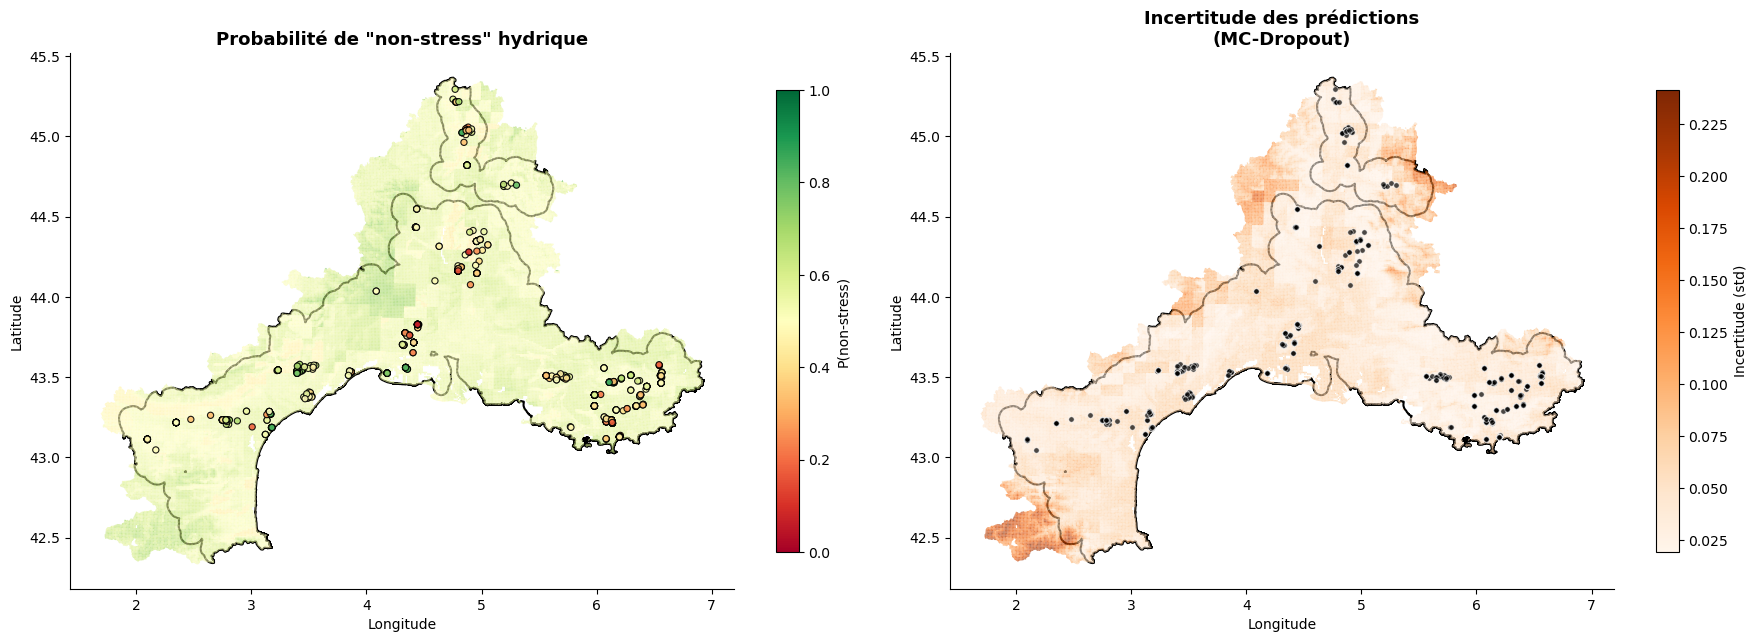


📊 Statistiques des prédictions MC-Dropout (100 samples) :
   Probabilité moyenne  : 0.551
   Incertitude moyenne  : 0.062
   Incertitude max      : 0.241


In [60]:
# Prédiction MC sur toutes les cellules valides
mean_preds, std_preds = predict_with_uncertainty(
    model     = best_fold["results"]["model"],
    X_tensor  = X_full_tensor,
    device    = device,
    n_samples = 100
)

# Reconstruction sur toute la grille
pred_mean_full = torch.full((num_cells,), float('nan'))
pred_std_full  = torch.full((num_cells,), float('nan'))
pred_mean_full[valid_indices] = mean_preds
pred_std_full[valid_indices]  = std_preds

# Carte double — prédiction + incertitude
grid_pred = grid_wgs84.copy()
grid_pred['ig_apex_pred'] = pred_mean_full.numpy()
grid_pred['uncertainty']  = pred_std_full.numpy()

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Carte prédiction
ax1 = axes[0]
study_zone_wgs.plot(ax=ax1, facecolor='none', edgecolor='black', linewidth=1.5)
grid_pred.dropna(subset=['ig_apex_pred']).plot(
    ax=ax1, column='ig_apex_pred', cmap='RdYlGn',
    legend=True, alpha=0.7,
    legend_kwds={'label': 'P(non-stress)', 'shrink': 0.6},
    vmin=0, vmax=1
)
# Observations superposées
data_zone_wgs.plot(
    ax=ax1, column='ig_apex', cmap='RdYlGn',
    markersize=20, edgecolor='black', linewidth=0.8,
    alpha=0.9, legend=False, vmin=0, vmax=1
)
ax1.set_title('Probabilité de "non-stress" hydrique', fontsize=13, fontweight='bold')

# Carte incertitude
ax2 = axes[1]
study_zone_wgs.plot(ax=ax2, facecolor='none', edgecolor='black', linewidth=1.5)
grid_pred.dropna(subset=['uncertainty']).plot(
    ax=ax2, column='uncertainty', cmap='Oranges',
    legend=True, alpha=0.7,
    legend_kwds={'label': 'Incertitude (std)', 'shrink': 0.6}
)
# Observations superposées (couleur fixe pour ne pas confondre avec l'incertitude)
data_zone_wgs.plot(
    ax=ax2, color='black',
    markersize=15, edgecolor='white', linewidth=0.5,
    alpha=0.7, legend=False
)
ax2.set_title('Incertitude des prédictions\n(MC-Dropout)', fontsize=13, fontweight='bold')

for ax in axes:
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print(f"\n📊 Statistiques des prédictions MC-Dropout ({100} samples) :")
valid_mean = pred_mean_full[~torch.isnan(pred_mean_full)]
valid_std  = pred_std_full[~torch.isnan(pred_std_full)]
print(f"   Probabilité moyenne  : {valid_mean.mean():.3f}")
print(f"   Incertitude moyenne  : {valid_std.mean():.3f}")
print(f"   Incertitude max      : {valid_std.max():.3f}")